In [91]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
from autoslo.workload_execution.trace import Trace
from autoslo.utils.colors import Palette
from autoslo.blueprint_selection.slo_resolver import SloResolver
import json

In [92]:
RUN_IDS = {
    'base_16': '1773009438', 
    'base_32': '1773009416',
    'base_64 (rais_100)': '1773030337',
    'ours': '1775490791'
}
colors = {
    'base_16': Palette.light_orange,
    'base_32': Palette.dark_orange, 
    'base_64 (rais_100)': Palette.dark_red,
    'ours': Palette.dark_green
}

labels = {
    'base_16': 'Single-cluster (16 RPU)',
    'base_32': 'Single-cluster (32 RPU)',
    'base_64 (rais_100)':  'Single-cluster (64 RPU)',
    'ours': 'Autoslo (1 month history)'
}

markers = {
    'base_16': 's',
    'base_32': 's',
    'base_64 (rais_100)': 's',
    'ours': 'o'
}

In [93]:
traces = {
    name: Trace(run_id) for name, run_id in RUN_IDS.items()
}

In [94]:
slo_resolver = SloResolver(
    default_slo_s=30.0, 
    slo_dict_filename='ext_tpcds1000_rpu16_p90_k4.0.yml'
)

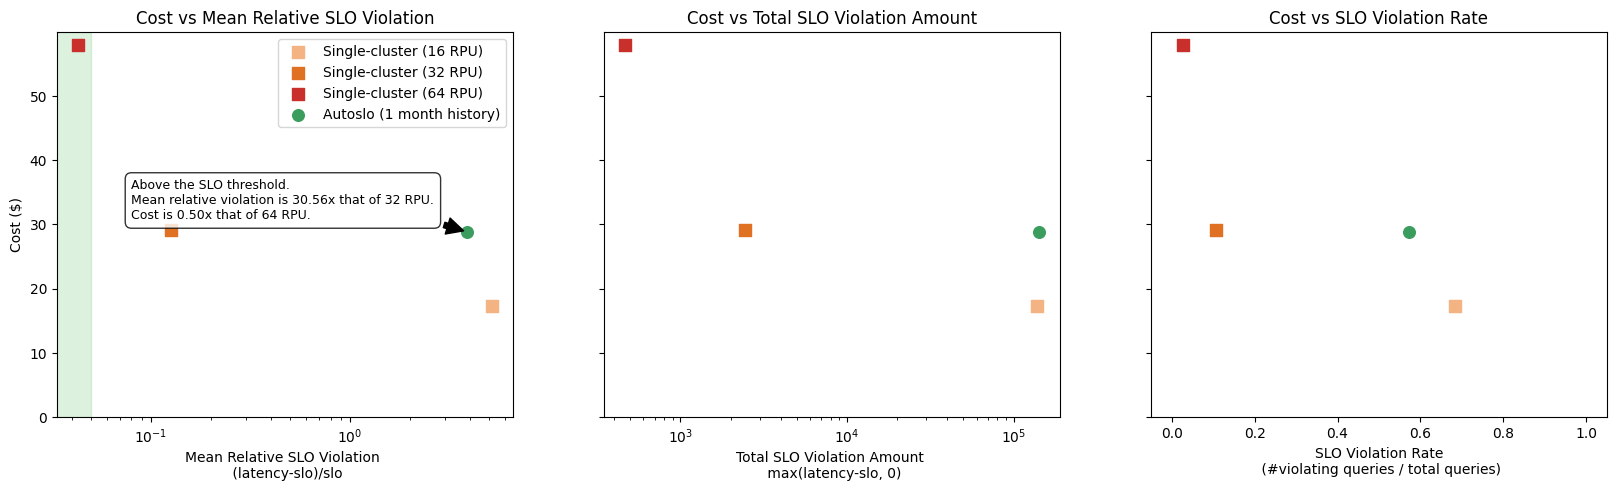

In [95]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

# One subplot per SLO metric:
for name, trace in traces.items():
    cost = float(sum(trace.costs))
    compliance_stats = trace.slo_compliance(resolver=slo_resolver)
    slo_violation_rate = compliance_stats["violates_slo"].mean()
    total_slo_violation_amount = compliance_stats["violation_amount_s"].sum()
    mean_relative_slo_violation = compliance_stats["violation_relative"].mean()
    axs[2].scatter(
        slo_violation_rate,
        cost,
        label=labels[name],
        color=colors[name],
        marker=markers[name],
        s=70,
    )
    axs[1].scatter(
        total_slo_violation_amount,
        cost,
        label=labels[name],
        color=colors[name],
        marker=markers[name],
        s=70,
    )
    axs[0].scatter(
        mean_relative_slo_violation,
        cost,
        label=labels[name],
        color=colors[name],
        marker=markers[name],
        s=70,
    )


# Plot setup
axs[0].set_ylabel("Cost ($)")
axs[0].set_ylim(bottom=0)
axs[0].set_xlabel("Mean Relative SLO Violation \n (latency-slo)/slo")
axs[1].set_xlabel("Total SLO Violation Amount \n max(latency-slo, 0)")
axs[2].set_xlabel("SLO Violation Rate\n (#violating queries / total queries)")
axs[0].set_title("Cost vs Mean Relative SLO Violation")
axs[1].set_title("Cost vs Total SLO Violation Amount")
axs[2].set_title("Cost vs SLO Violation Rate")

axs[0].legend()

threshold = 0.05

# In ax[0], plot the background of the region to the left of threshold light_gray
axs[0].axvspan(0, threshold, color=Palette.light_green, zorder=-100, alpha=0.3)

# To the right of our point, print an annotation with three lines of text:
# - whether its mean relative violation is above or below the threshold
# - The fraction of its mean relative violation compared to 32 RPU
# - The fraction of its cost compared to 64 RPU
ours_mean_relative_violation = traces['ours'].slo_compliance(resolver=slo_resolver)["violation_relative"].mean()
base_32_mean_relative_violation = traces['base_32'].slo_compliance(resolver=slo_resolver)["violation_relative"].mean()
ours_cost = float(sum(traces['ours'].costs))
base_64_cost = float(sum(traces['base_64 (rais_100)'].costs))
annotation_text = f"{'Above' if ours_mean_relative_violation > threshold else 'Below'} the SLO threshold.\n"
annotation_text += f"Mean relative violation is {ours_mean_relative_violation / base_32_mean_relative_violation:.2f}x that of 32 RPU.\n"
annotation_text += f"Cost is {ours_cost / base_64_cost:.2f}x that of 64 RPU."

# Pick a position so that it's inside the plot area
x_pos = 0.08
y_pos = ours_cost + 2

axs[0].annotate(
    annotation_text,
    xy=(ours_mean_relative_violation, ours_cost),
    xytext=(x_pos, y_pos),
    arrowprops=dict(facecolor='black', shrink=0.1),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", edgecolor='black', facecolor='white', alpha=0.8)
)   


relative_eps = 0.05
# Adjust min/max so that there is the specified amount of relative padding
# around the points. This is just for aesthetics.
# ax0_range = axs[0].get_xlim()[1] - axs[0].get_xlim()[0]
# new_min = axs[0].get_xlim()[0] - relative_eps * ax0_range
# new_max = axs[0].get_xlim()[1] + relative_eps * ax0_range
# axs[0].set_xlim(new_min, new_max)

axs[0].set_xscale("log")
axs[1].set_xscale("log")

ax2_range = 1
new_min = -relative_eps
new_max = 1 + relative_eps
axs[2].set_xlim(new_min, new_max)

plt.savefig("cost_vs_compliance.png", bbox_inches="tight", dpi=300)
plt.show()

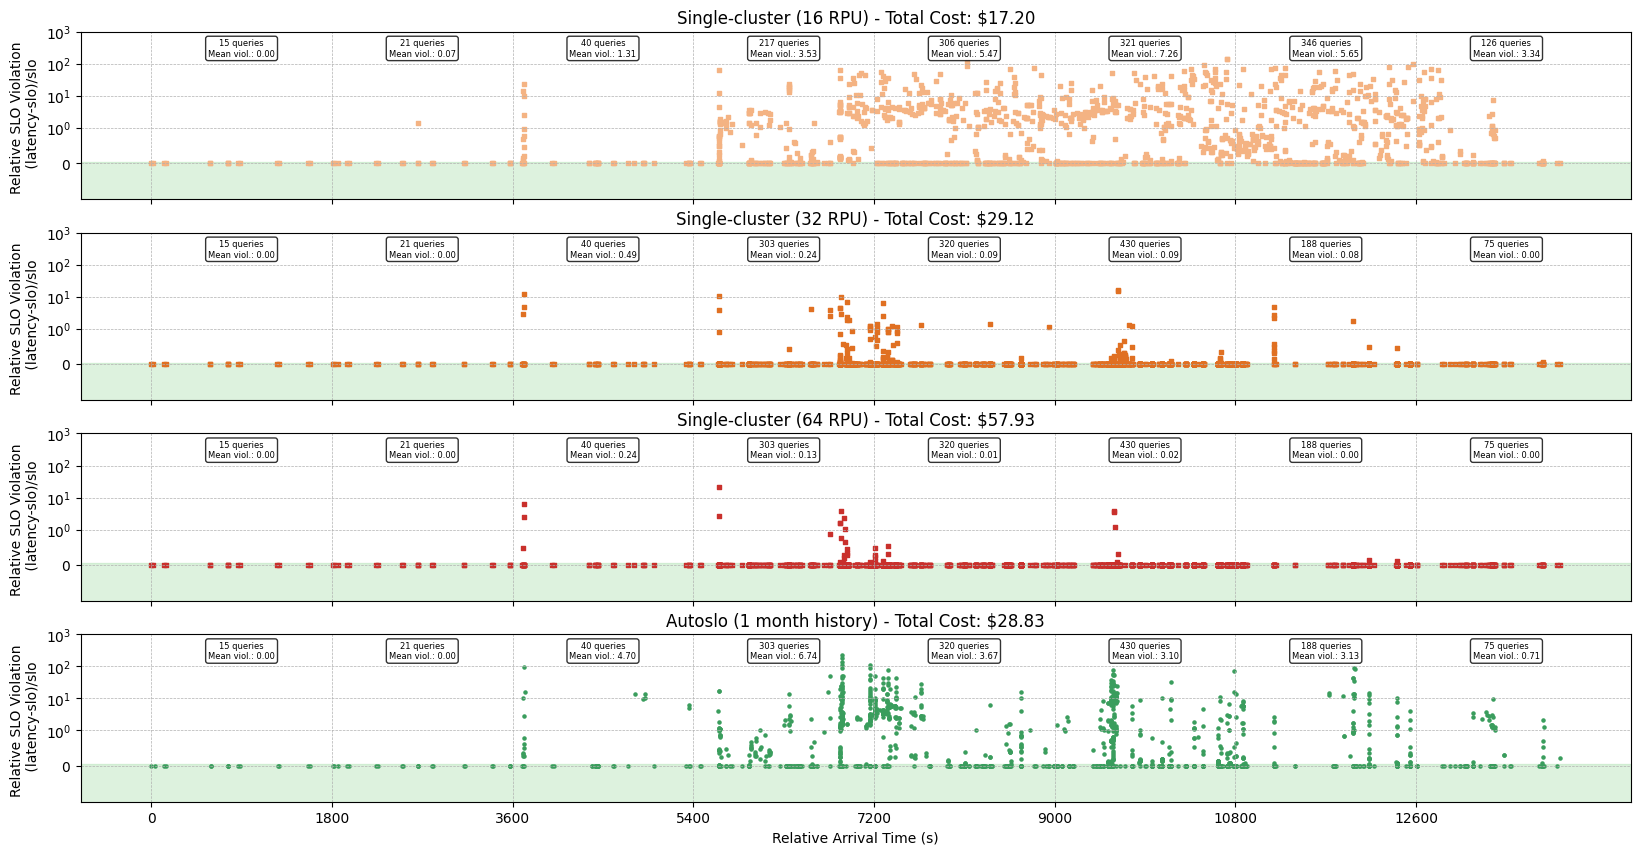

In [96]:
# Plot a timeseries for each run. Each timeseries should have one point per query. The x axis of each point should be the arrival time
# of that query. The y coordinate should be the point's relative SLO violation. 

fig, axs = plt.subplots(len(traces), 1, figsize=(20, 10), sharex=True, sharey=True)

for i, (name, trace) in enumerate(traces.items()):
    relative_arrival_times = trace.relative_arrival_times_s()
    compliance_stats = trace.slo_compliance(resolver=slo_resolver)
    merged = pd.merge(
        pd.DataFrame({"relative_arrival_times_s": relative_arrival_times}),
        compliance_stats[["violation_relative"]],
        left_index=True,
        right_index=True
    )
    axs[i].scatter(
        merged["relative_arrival_times_s"],
        merged["violation_relative"],
        label=labels[name],
        color=colors[name],
        marker=markers[name],
        s=5,
    )
    threshold = 0.05
    axs[i].axhspan(-2, threshold, color=Palette.light_green, zorder=-100, alpha=0.3)
    axs[i].set_title(f"{labels[name]} - Total Cost: ${float(sum(trace.costs)):.2f}")
    axs[i].set_ylabel("Relative SLO Violation \n (latency-slo)/slo")
    axs[i].set_ylim(bottom = -1, top=1000)
    axs[i].set_yscale("symlog", linthresh=1)

    # Place x ticks every half an hour
    axs[i].set_xticks(range(0, int(max(relative_arrival_times)) + 1, 1800))

    axs[i].grid(True, which="both", ls="--", linewidth=0.5)

    # Add a text annotation near the top for every half-hout bucket that says
    # the number of queries and the mean relative violation of queries in that bucket
    for bucket_start in range(0, int(max(relative_arrival_times)) + 1, 1800):
        bucket_end = bucket_start + 1800
        bucket_data = merged[(merged["relative_arrival_times_s"] >= bucket_start) & (merged["relative_arrival_times_s"] < bucket_end)]
        if len(bucket_data) > 0:
            mean_violation = bucket_data["violation_relative"].mean()
            axs[i].annotate(
                f"{len(bucket_data)} queries\nMean viol.: {mean_violation:.2f}",
                xy=(bucket_start + 900, 150),
                xytext=(0, 0),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=6,
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white', alpha=0.8)
            )
    

axs[len(traces)-1].set_xlabel("Relative Arrival Time (s)")
plt.show()